<a href="https://colab.research.google.com/github/mohsenSarvariHero/parkinson-gene-signature-ml/blob/main/start.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print("hello")

hello


In [5]:
import pandas as pd
data = pd.read_csv('GSE99039_series_matrix.txt' , sep="\t" , comment="!" , index_col=0)

print("Shape of data:", data.shape)



Shape of data: (8639, 558)


In [6]:

print(data.head())

           GSM2630758  GSM2630759  GSM2630760  GSM2630761  GSM2630762  \
ID_REF                                                                  
1007_s_at       5.397       4.952       5.331       5.601       5.087   
1053_at         5.199       5.198       4.970       5.816       5.443   
117_at          8.327       8.589       8.629       9.628       9.449   
121_at          7.042       6.935       7.701       6.909       7.284   
1255_g_at       2.463       2.388       2.349       2.268       2.407   

           GSM2630763  GSM2630764  GSM2630765  GSM2630766  GSM2630767  ...  \
ID_REF                                                                 ...   
1007_s_at       5.921       5.153       5.341       5.261       5.147  ...   
1053_at         5.430       5.243       5.167       5.324       5.489  ...   
117_at          9.230       9.269       9.095       9.184       8.623  ...   
121_at          7.153       6.850       7.541       6.918       6.714  ...   
1255_g_at       2.13

In [7]:
print(data.columns[:10])

Index(['GSM2630758', 'GSM2630759', 'GSM2630760', 'GSM2630761', 'GSM2630762',
       'GSM2630763', 'GSM2630764', 'GSM2630765', 'GSM2630766', 'GSM2630767'],
      dtype='object')


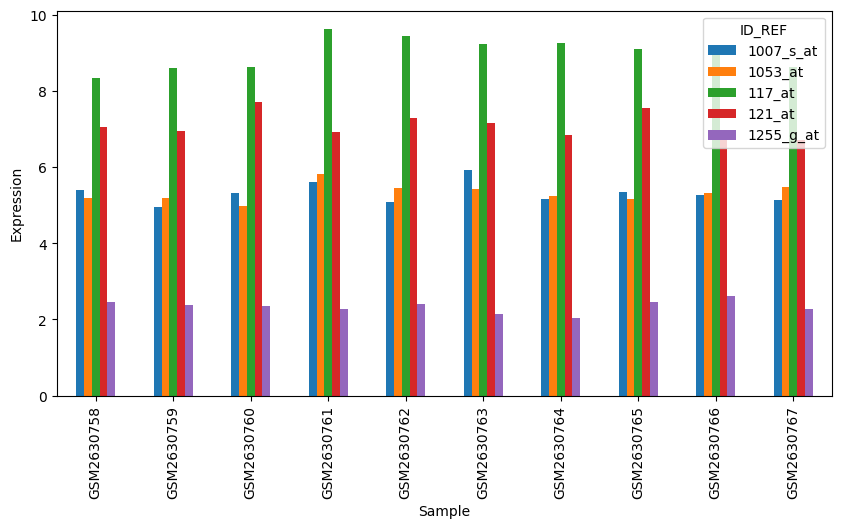

In [8]:
import matplotlib.pyplot as plt

# انتخاب 5 ژن اول و رسم نمودار expression
data.iloc[:5, :10].T.plot(kind='bar', figsize=(10,5))
plt.xlabel("Sample")
plt.ylabel("Expression")
plt.show()

In [10]:
# خواندن 20 سطر اول فایل Series Matrix
with open("GSE99039_series_matrix.txt") as f:
    for _ in range(20):
        print(f.readline())

!Series_title	"A blood-based gene signature characterizing Idiopathic Parkinson's disease"

!Series_geo_accession	"GSE99039"

!Series_status	"Public on May 20 2017"

!Series_submission_date	"May 17 2017"

!Series_last_update_date	"Jul 25 2021"

!Series_pubmed_id	"28916538"

!Series_summary	"Establishing reliable biomarkers for assessing and validating clinical diagnosis at early prodromal stages of Parkinson’s disease is crucial for developing therapies to slow or halt disease progression. Here, we present the largest study to date using whole blood gene expression profiling from over 500 individuals to identify an 87-gene blood-based signature. Our gene signature effectively differentiates between idiopathic PD patients and controls in both a validation cohort and an independent test cohort, and further highlights mitochondrial metabolism and ubiquitination/proteasomal degradation as potential pathways disrupted in Parkinson’s disease."

!Series_overall_design	"This repository contain

In [11]:
with open("GSE99039_series_matrix.txt") as f:
    for _ in range(20):
        print(f.readline())

!Series_title	"A blood-based gene signature characterizing Idiopathic Parkinson's disease"

!Series_geo_accession	"GSE99039"

!Series_status	"Public on May 20 2017"

!Series_submission_date	"May 17 2017"

!Series_last_update_date	"Jul 25 2021"

!Series_pubmed_id	"28916538"

!Series_summary	"Establishing reliable biomarkers for assessing and validating clinical diagnosis at early prodromal stages of Parkinson’s disease is crucial for developing therapies to slow or halt disease progression. Here, we present the largest study to date using whole blood gene expression profiling from over 500 individuals to identify an 87-gene blood-based signature. Our gene signature effectively differentiates between idiopathic PD patients and controls in both a validation cohort and an independent test cohort, and further highlights mitochondrial metabolism and ubiquitination/proteasomal degradation as potential pathways disrupted in Parkinson’s disease."

!Series_overall_design	"This repository contain

In [13]:
metadata_lines = []

with open("GSE99039_series_matrix.txt") as f:
    for line in f:
        line = line.strip()
        if line.startswith("!Sample_title") or "disease state" in line:
            metadata_lines.append(line)

# نمایش 10 خط اول
metadata_lines[:10]

['!Sample_title\t"E7R_039a01"\t"E7R_039a02"\t"E7R_039a03"\t"E7R_039a04"\t"E7R_039a05"\t"E7R_039a07"\t"E7R_039a08"\t"E7R_039a09"\t"E7R_039a10"\t"E7R_039a102"\t"E7R_039a103"\t"E7R_039a104"\t"E7R_039a105"\t"E7R_039a106"\t"E7R_039a108"\t"E7R_039a109"\t"E7R_039a11"\t"E7R_039a110"\t"E7R_039a111"\t"E7R_039a112"\t"E7R_039a113"\t"E7R_039a114"\t"E7R_039a13"\t"E7R_039a14"\t"E7R_039a16"\t"E7R_039a18"\t"E7R_039a20"\t"E7R_039a23"\t"E7R_039a30"\t"E7R_039a34"\t"E7R_039a35"\t"E7R_039a49"\t"E7R_039a57"\t"E7R_039a60"\t"E7R_039a63"\t"E7R_039a64"\t"E7R_039a68"\t"E7R_039a69"\t"E7R_039a71"\t"E7R_039a72"\t"E7R_039a79"\t"E7R_039a80"\t"E7R_039a81"\t"E7R_039a82"\t"E7R_039a85"\t"E7R_039a87"\t"E7R_039a89"\t"E7R_039a90"\t"E7R_039a91"\t"E7R_039a92"\t"E7R_039a94"\t"E7R_039a95"\t"E7R_039a96"\t"E7R_039a98"\t"E7R_039a99"\t"E8R_012a01"\t"E8R_012a02"\t"E8R_012a03"\t"E8R_012a04_2"\t"E8R_012a05"\t"E8R_012a06"\t"E8R_012a07"\t"E8R_012a08"\t"E8R_012a09"\t"E8R_012a11"\t"E8R_012a12"\t"E8R_012a14"\t"E8R_012a16"\t"E8R_012a17_2"\t"

In [14]:
line = '!Sample_title\t"E7R_039a01"\t"E7R_039a02"\t"E7R_039a03"'  # نمونه کوتاه
parts = line.split("\t")
gsm_ids = [p.strip('"') for p in parts[1:]]  # حذف علامت " و اولین عنصر

print(gsm_ids)
# ['E7R_039a01', 'E7R_039a02', 'E7R_039a03']

['E7R_039a01', 'E7R_039a02', 'E7R_039a03']


In [15]:
line = '!Sample_characteristics_ch1\t"control"\t"control"\t"PD"'  # نمونه کوتاه
parts = line.split("\t")
labels = [p.strip('"') for p in parts[1:]]

print(labels)
# ['control', 'control', 'PD']

['control', 'control', 'PD']


In [16]:

import pandas as pd

# مثال کوتاه
gsm_ids = ['E7R_039a01', 'E7R_039a02', 'E7R_039a03']
labels = ['control', 'control', 'PD']

# ساخت DataFrame
sample_info = pd.DataFrame({
    'GSM': gsm_ids,
    'label': labels
})

print(sample_info)

          GSM    label
0  E7R_039a01  control
1  E7R_039a02  control
2  E7R_039a03       PD


In [19]:
data_T = data.T
data_T['label'] = labels


ValueError: Length of values (549) does not match length of index (558)

In [21]:
labels = ['control']*233 + ['PD']*205 + ['NDD']*48 + ['control_genetic']*22 + ['PD_genetic']*50  # تعداد دقیق باید جمعش 558 شود
data_T['label'] = labels

In [22]:
data_T = data.T
data_T['label'] = labels


In [23]:
# نمایش چند سطر اول دیتاست با لیبل
print(data_T.head())

# نمایش ستون‌ها
print(data_T.columns)

# چک کردن تعداد نمونه‌ها در هر کلاس
print(data_T['label'].value_counts())

ID_REF      1007_s_at  1053_at  117_at  121_at  1255_g_at  1294_at  1316_at  \
GSM2630758      5.397    5.199   8.327   7.042      2.463    7.753    5.118   
GSM2630759      4.952    5.198   8.589   6.935      2.388    8.210    5.107   
GSM2630760      5.331    4.970   8.629   7.701      2.349    7.744    5.523   
GSM2630761      5.601    5.816   9.628   6.909      2.268    7.670    4.579   
GSM2630762      5.087    5.443   9.449   7.284      2.407    8.157    4.603   

ID_REF      1320_at  1405_i_at  1431_at  ...  1567272_at  1567273_at  \
GSM2630758    3.170     11.152    2.564  ...       2.650       2.809   
GSM2630759    2.677     11.029    2.603  ...       2.453       2.681   
GSM2630760    3.072     11.159    2.664  ...       2.807       3.071   
GSM2630761    3.025     10.528    2.551  ...       2.622       2.763   
GSM2630762    2.861     11.393    2.629  ...       2.596       2.846   

ID_REF      1567274_at  1567277_at  1567280_at  1567281_at  1567282_at  \
GSM2630758       6